실습6. 시각화 리포트통합·저장
- 핵심 그래프 4개를 2×2로 모아 리포트로 저장

목표
- 핵심 그래프 4개를 2×2로 모아 리포트 파일로 저장

단계
- subplots로 2×2 격자를 만들기
- 분포·박스플롯·산점도·heatmap을 네 칸에 배치
- savefig로 리포트를 이미지 파일로 저장(show보다 먼저)

예상 결과
- 분포·박스·관계·상관을 담은 2×2 리포트 저장

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 한글깨짐 해결
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [20]:
df = pd.read_csv("../data/18_열처리.csv")

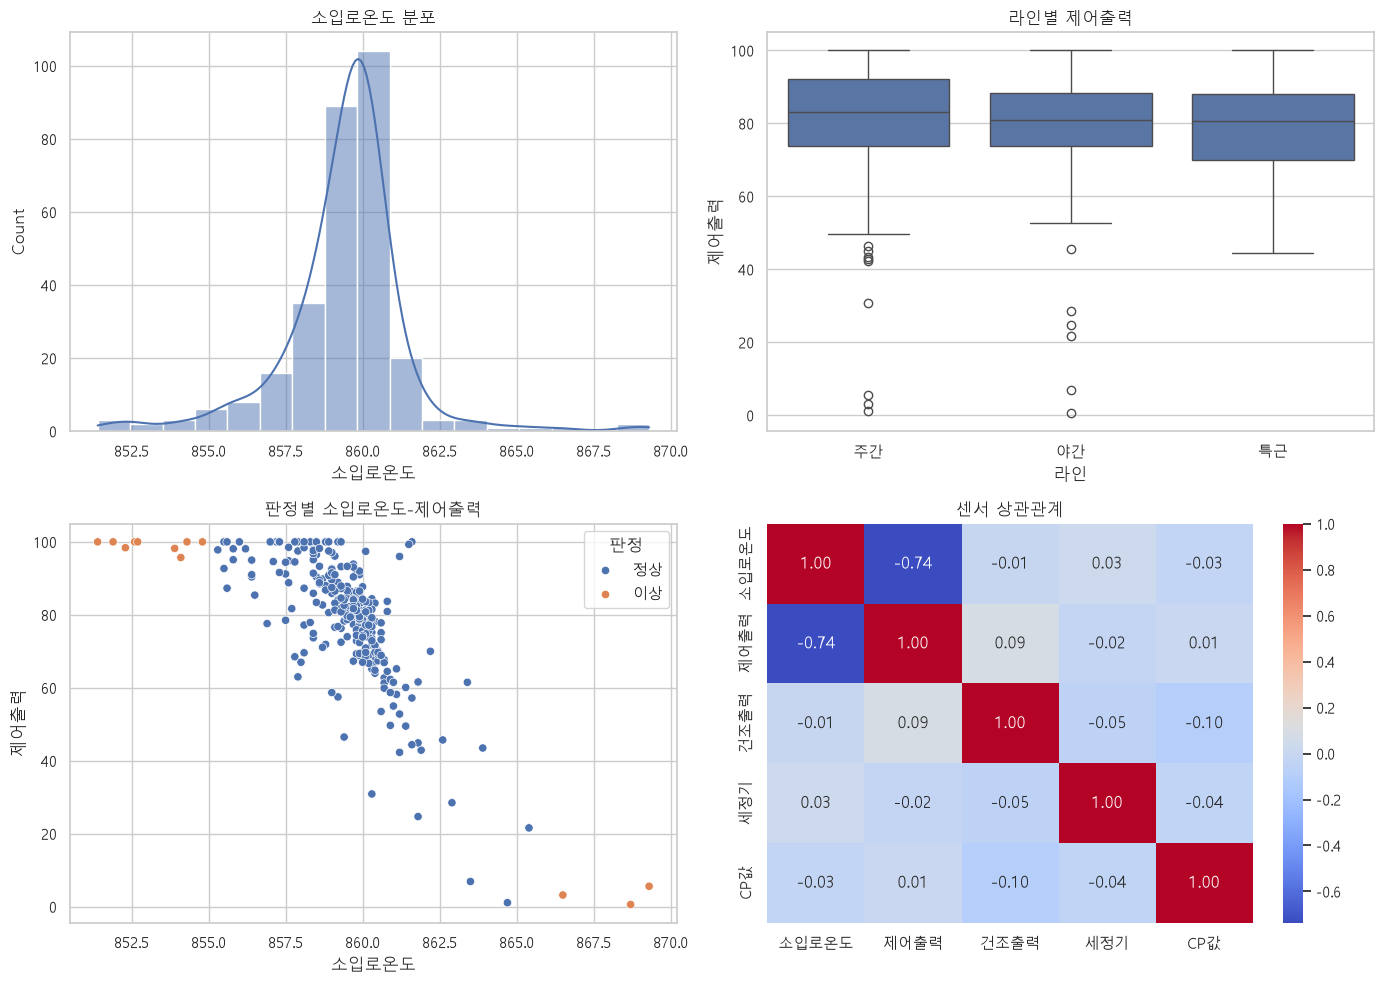

In [21]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
corr = df.corr(numeric_only=True)

sns.histplot(data=df, x="소입로온도", ax=axs[0][0], bins=17, kde=True)
axs[0][0].set_title("소입로온도 분포")

sns.boxplot(data=df, x="라인", y="제어출력", ax=axs[0][1])
axs[0][1].set_title("라인별 제어출력")

sns.scatterplot(data=df, x="소입로온도", y="제어출력", hue="판정", ax=axs[1][0])
axs[1][0].set_title("판정별 소입로온도-제어출력")

sns.heatmap(data=corr, annot=True, fmt="0.2f", cmap="coolwarm", ax=axs[1][1])
axs[1][1].set_title("센서 상관관계")

plt.tight_layout()
plt.show()